In [1]:
import os, glob, re
import xarray as xr
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

 "number_of_characteristic_subbasins": 2,
    "average_height_difference_between_bands": 500,
    "number_of_intraband_clusters": 50,
    "subbasin_clustering_covariates": [
      "dem",
      "lats",
      "lons"
    ],
    "intraband_clustering_covariates": [
      "dem",
      "lats",
      "lons"
    ],

In [32]:
import os
import netCDF4 as nc

# --------------------------------------------------
# PATHS
# --------------------------------------------------
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "20 clusters":  base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/",
    "50 clusters":  base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_4/",
    "75 clusters":  base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/",
    "125 clusters": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_33/",
    "200 clusters": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_5/",
}

cid = 1

# --------------------------------------------------
# LOOP THROUGH RUNS
# --------------------------------------------------
for label, path in runs.items():

    input_file = os.path.join(
        path,
        f"{cid}/input_file.nc"
    )

    print("\n----------------------------------")
    print(label)

    with nc.Dataset(input_file) as ds:

        # HRU variable from parameters group
        hru = ds.groups["parameters"].variables["hru"][:]

        nhru = len(hru)

        print("Number of HRUs:", nhru)

        print("First HRU ID:", int(hru[0]))
        print("Last HRU ID:", int(hru[-1]))

        print("HRU IDs start from zero:",
              np.min(hru) == 0)

        print("Unique HRUs:",
              len(set(hru)) == nhru)


----------------------------------
20 clusters
Number of HRUs: 80
First HRU ID: 0
Last HRU ID: 79
HRU IDs start from zero: True
Unique HRUs: True

----------------------------------
50 clusters
Number of HRUs: 200
First HRU ID: 0
Last HRU ID: 199
HRU IDs start from zero: True
Unique HRUs: True

----------------------------------
75 clusters
Number of HRUs: 300
First HRU ID: 0
Last HRU ID: 299
HRU IDs start from zero: True
Unique HRUs: True

----------------------------------
125 clusters
Number of HRUs: 500
First HRU ID: 0
Last HRU ID: 499
HRU IDs start from zero: True
Unique HRUs: True

----------------------------------
200 clusters
Number of HRUs: 800
First HRU ID: 0
Last HRU ID: 799
HRU IDs start from zero: True
Unique HRUs: True


Reading: Low
20 intraband clusters | 80 HRU
Reading: Moderate
50 intraband clusters | 200 HRU
Reading: Medium
75 intraband clusters | 300 HRU
Reading: High
125 intraband clusters | 500 HRU
Reading: Very High
200 intraband clusters | 500 HRU


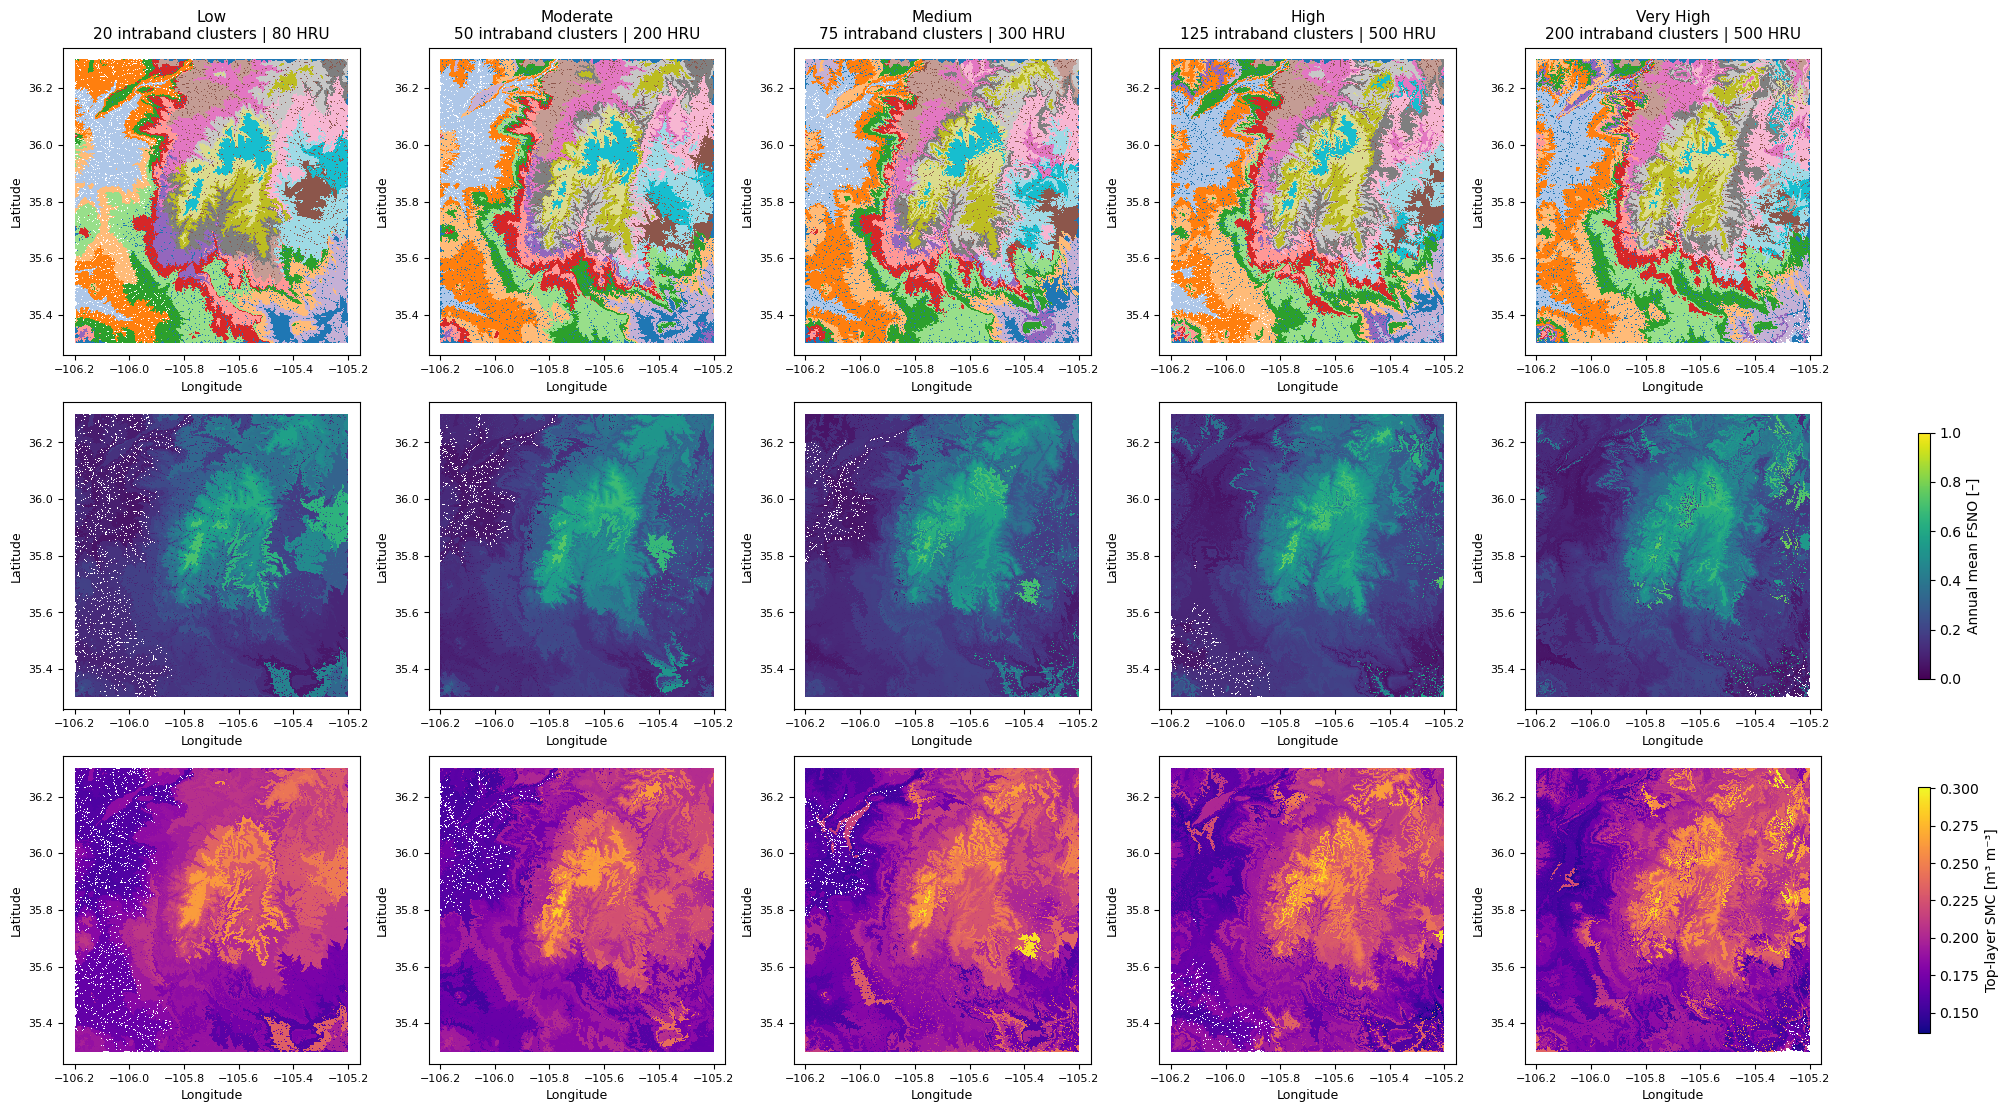

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/sensitivity_plots/HRU_Effects/Figure_A_HRU_Effect_FSNO_SMC_toplayer.png


In [33]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# --------------------------------------------------
# PATHS
# --------------------------------------------------
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Low\n20 intraband clusters | 80 HRU": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/",
    "Moderate\n50 intraband clusters | 200 HRU": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_4/",
    "Medium\n75 intraband clusters | 300 HRU": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/",
    "High\n125 intraband clusters | 500 HRU": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_33/",
    "Very High\n200 intraband clusters | 500 HRU": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_5/",
}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/sensitivity_plots/HRU_Effects"
os.makedirs(outputdir, exist_ok=True)

buffer = 250

# --------------------------------------------------
# FUNCTIONS
# --------------------------------------------------
def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out


def read_fsno(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["fsno"][:])
    fp.close()
    return data


def read_smc_top(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    smc = np.array(fp.groups["data"].variables["smc"][:])
    fp.close()

    # smc shape is usually (time, hru, soil_layer)
    # use top soil layer only
    smc_top = smc[:, :, 0]

    return smc_top


def clean_and_crop(arr):
    arr = np.where(arr == -9999.0, np.nan, arr)

    return arr[
        buffer:arr.shape[0] - buffer + 1,
        buffer:arr.shape[1] - buffer + 1
    ]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    # HRU map
    hru_map = np.copy(hrus)
    hru_map = np.where((cids == 1) & (hrus > 0), hru_map, np.nan)

    # Annual mean FSNO
    fsno = read_fsno(path)
    fsno_mean_hru = np.nanmean(fsno, axis=0)

    fsno_map = place_data(
        tmp,
        fsno_mean_hru,
        hrus,
        cids,
        1
    )

    # Annual mean top-layer SMC
    smc_top = read_smc_top(path)
    smc_top_mean_hru = np.nanmean(smc_top, axis=0)

    smc_top_map = place_data(
        tmp,
        smc_top_mean_hru,
        hrus,
        cids,
        1
    )

    return (
        clean_and_crop(hru_map),
        clean_and_crop(fsno_map),
        clean_and_crop(smc_top_map)
    )


# --------------------------------------------------
# COORDINATES
# --------------------------------------------------
first_path = list(runs.values())[0]
meta = gdal_tools.retrieve_metadata(first_path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(meta["minx"], meta["maxx"], meta["nx"])
coord_yy0 = np.linspace(meta["miny"], meta["maxy"], meta["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

# --------------------------------------------------
# READ ALL MAPS
# --------------------------------------------------
hru_maps = []
fsno_maps = []
smc_maps = []
labels = []

for label, path in runs.items():
    print("Reading:", label)

    hru_map, fsno_map, smc_map = get_maps(path)

    hru_maps.append(hru_map)
    fsno_maps.append(fsno_map)
    smc_maps.append(smc_map)
    labels.append(label)

# --------------------------------------------------
# NORMALIZATION
# --------------------------------------------------
fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

smc_min = np.nanmin([np.nanmin(m) for m in smc_maps])
smc_max = np.nanmax([np.nanmax(m) for m in smc_maps])

smc_norm = colors.Normalize(
    vmin=smc_min,
    vmax=smc_max
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
ncols = len(labels)

fig, axes = plt.subplots(
    3,
    ncols,
    figsize=(4.0 * ncols, 11),
    constrained_layout=True
)

if ncols == 1:
    axes = axes.reshape(3, 1)

for col in range(ncols):

    im0 = axes[0, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(hru_maps[col]),
        cmap="tab20",
        shading="auto"
    )

    axes[0, col].set_title(labels[col], fontsize=11)

    im1 = axes[1, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(fsno_maps[col]),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    im2 = axes[2, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(smc_maps[col]),
        cmap="plasma",
        norm=smc_norm,
        shading="auto"
    )

# --------------------------------------------------
# AXIS LABELS
# --------------------------------------------------
axes[0, 0].set_ylabel("HRU distribution", fontsize=12)
axes[1, 0].set_ylabel("Annual mean FSNO", fontsize=12)
axes[2, 0].set_ylabel("Annual mean top-layer SMC", fontsize=12)

for i in range(3):
    for j in range(ncols):
        axes[i, j].set_xlabel("Longitude", fontsize=9)
        axes[i, j].set_ylabel("Latitude", fontsize=9)
        axes[i, j].tick_params(labelsize=8)

# --------------------------------------------------
# COLORBARS
# --------------------------------------------------
'''
cbar0 = fig.colorbar(
    im0,
    ax=axes[0, :],
    shrink=0.8
)
cbar0.set_label("HRU ID")
'''
cbar1 = fig.colorbar(
    im1,
    ax=axes[1, :],
    shrink=0.8
)
cbar1.set_label("Annual mean FSNO [–]")

cbar2 = fig.colorbar(
    im2,
    ax=axes[2, :],
    shrink=0.8
)
cbar2.set_label("Top-layer SMC [m³ m⁻³]")

# --------------------------------------------------
# SAVE
# --------------------------------------------------
outfile = os.path.join(
    outputdir,
    "Figure_A_HRU_Effect_FSNO_SMC_toplayer.png"
)

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", outfile)

Reading reference run (200 clusters)
Processing: 20
Processing: 50
Processing: 75
Processing: 125
Processing: 200


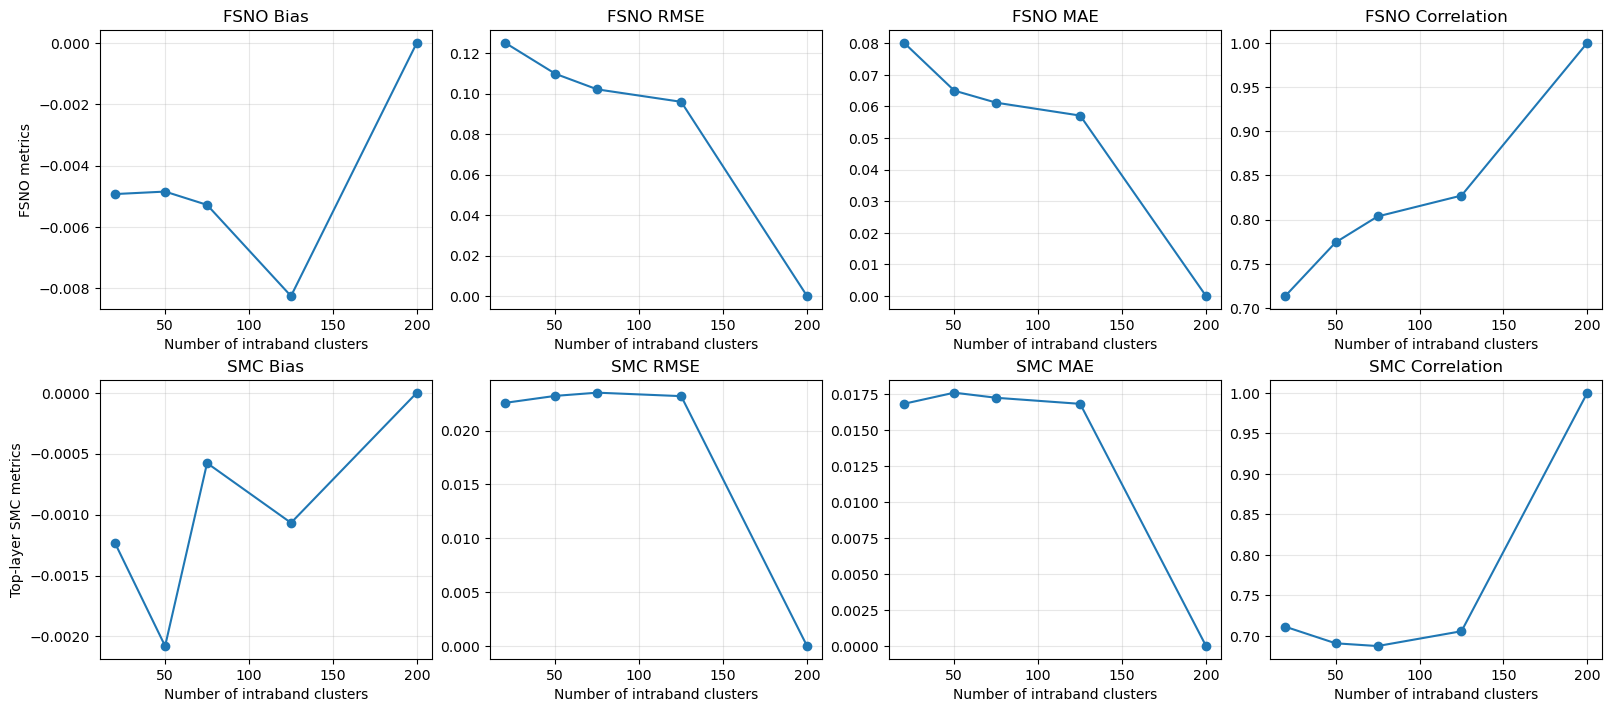

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/sensitivity_plots/HRU_Effects/Figure_C_HRU_Convergence_Metrics.png


In [35]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import geospatialtools.gdal_tools as gdal_tools

# --------------------------------------------------
# PATHS
# --------------------------------------------------
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    20: base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/",
    50: base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_4/",
    75: base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/",
    125: base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_33/",
    200: base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_5/",
}

reference_clusters = 200
reference_path = runs[reference_clusters]

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/sensitivity_plots/HRU_Effects"
)

os.makedirs(outputdir, exist_ok=True)

buffer = 250

# --------------------------------------------------
# FUNCTIONS
# --------------------------------------------------
def place_data(tmp, model, hrus, cids, cid_val=1):

    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):

            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (
                (ucid == cid_val)
                and (hru > 0)
                and (hru <= nhru)
            ):
                out[i, j] = model[hru - 1]

    return out


def clean_and_crop(arr):

    arr = np.where(
        arr == -9999.0,
        np.nan,
        arr
    )

    return arr[
        buffer:arr.shape[0]-buffer+1,
        buffer:arr.shape[1]-buffer+1
    ]


def read_fsno(path):

    fp = nc.Dataset(
        path + "/output_data/1/2016-01-01.nc"
    )

    data = np.array(
        fp.groups["data"].variables["fsno"][:]
    )

    fp.close()

    return data


def read_smc_top(path):

    fp = nc.Dataset(
        path + "/output_data/1/2016-01-01.nc"
    )

    smc = np.array(
        fp.groups["data"].variables["smc"][:]
    )

    fp.close()

    return smc[:, :, 0]


def get_maps(path):

    hrus = gdal_tools.read_raster(
        path + "postprocess/hrus.vrt"
    )

    cids = gdal_tools.read_raster(
        path + "postprocess/cids.vrt"
    )

    tmp = np.full(
        hrus.shape,
        -9999.0
    )

    # FSNO
    fsno = read_fsno(path)

    fsno_mean_hru = np.nanmean(
        fsno,
        axis=0
    )

    fsno_map = place_data(
        tmp,
        fsno_mean_hru,
        hrus,
        cids,
        1
    )

    # SMC top layer
    smc_top = read_smc_top(path)

    smc_mean_hru = np.nanmean(
        smc_top,
        axis=0
    )

    smc_map = place_data(
        tmp,
        smc_mean_hru,
        hrus,
        cids,
        1
    )

    return (
        clean_and_crop(fsno_map),
        clean_and_crop(smc_map)
    )

# --------------------------------------------------
# METRICS
# --------------------------------------------------
def compute_metrics(model, reference):

    mask = (
        np.isfinite(model)
        & np.isfinite(reference)
    )

    m = model[mask]
    r = reference[mask]

    diff = m - r

    bias = np.mean(diff)

    rmse = np.sqrt(
        np.mean(diff**2)
    )

    mae = np.mean(
        np.abs(diff)
    )

    corr = pearsonr(m, r)[0]

    return bias, rmse, mae, corr

# --------------------------------------------------
# REFERENCE MAPS
# --------------------------------------------------
print("Reading reference run (200 clusters)")

fsno_ref, smc_ref = get_maps(
    reference_path
)

# --------------------------------------------------
# STORAGE
# --------------------------------------------------
cluster_vals = []

fsno_bias = []
fsno_rmse = []
fsno_mae = []
fsno_corr = []

smc_bias = []
smc_rmse = []
smc_mae = []
smc_corr = []

# --------------------------------------------------
# LOOP THROUGH RUNS
# --------------------------------------------------
for nclusters, path in runs.items():

    print("Processing:", nclusters)

    fsno_map, smc_map = get_maps(path)

    # FSNO metrics
    bias, rmse, mae, corr = compute_metrics(
        fsno_map,
        fsno_ref
    )

    fsno_bias.append(bias)
    fsno_rmse.append(rmse)
    fsno_mae.append(mae)
    fsno_corr.append(corr)

    # SMC metrics
    bias, rmse, mae, corr = compute_metrics(
        smc_map,
        smc_ref
    )

    smc_bias.append(bias)
    smc_rmse.append(rmse)
    smc_mae.append(mae)
    smc_corr.append(corr)

    cluster_vals.append(nclusters)

# --------------------------------------------------
# SORT
# --------------------------------------------------
sort_idx = np.argsort(cluster_vals)

cluster_vals = np.array(cluster_vals)[sort_idx]

fsno_bias = np.array(fsno_bias)[sort_idx]
fsno_rmse = np.array(fsno_rmse)[sort_idx]
fsno_mae = np.array(fsno_mae)[sort_idx]
fsno_corr = np.array(fsno_corr)[sort_idx]

smc_bias = np.array(smc_bias)[sort_idx]
smc_rmse = np.array(smc_rmse)[sort_idx]
smc_mae = np.array(smc_mae)[sort_idx]
smc_corr = np.array(smc_corr)[sort_idx]

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 7),
    constrained_layout=True
)

# --------------------------------------------------
# FSNO
# --------------------------------------------------
axes[0,0].plot(cluster_vals, fsno_bias, marker='o')
axes[0,0].set_title("FSNO Bias")

axes[0,1].plot(cluster_vals, fsno_rmse, marker='o')
axes[0,1].set_title("FSNO RMSE")

axes[0,2].plot(cluster_vals, fsno_mae, marker='o')
axes[0,2].set_title("FSNO MAE")

axes[0,3].plot(cluster_vals, fsno_corr, marker='o')
axes[0,3].set_title("FSNO Correlation")

# --------------------------------------------------
# SMC
# --------------------------------------------------
axes[1,0].plot(cluster_vals, smc_bias, marker='o')
axes[1,0].set_title("SMC Bias")

axes[1,1].plot(cluster_vals, smc_rmse, marker='o')
axes[1,1].set_title("SMC RMSE")

axes[1,2].plot(cluster_vals, smc_mae, marker='o')
axes[1,2].set_title("SMC MAE")

axes[1,3].plot(cluster_vals, smc_corr, marker='o')
axes[1,3].set_title("SMC Correlation")

# --------------------------------------------------
# FORMAT
# --------------------------------------------------
for i in range(2):
    for j in range(4):

        axes[i,j].set_xlabel(
            "Number of intraband clusters"
        )

        axes[i,j].grid(
            alpha=0.3
        )

# --------------------------------------------------
# ROW LABELS
# --------------------------------------------------
axes[0,0].set_ylabel("FSNO metrics")
axes[1,0].set_ylabel("Top-layer SMC metrics")

# --------------------------------------------------
# SAVE
# --------------------------------------------------
outfile = os.path.join(
    outputdir,
    "Figure_C_HRU_Convergence_Metrics.png"
)

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", outfile)

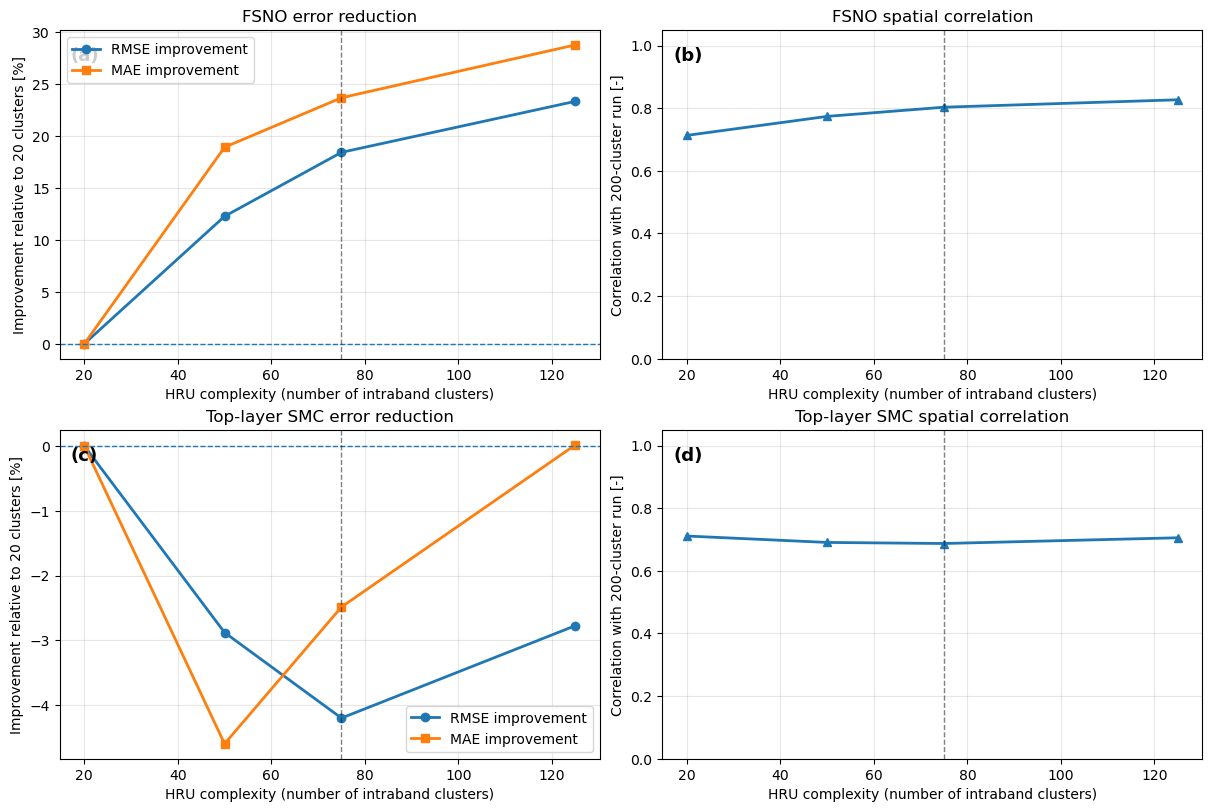

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/sensitivity_plots/HRU_Effects/Figure_C_ErrorReduction_Correlation_HRU_clusters_panel.png


In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# INCLUDE ONLY 20, 50, 75, 125
# 200 is the reference run
# --------------------------------------------------
mask = cluster_vals != 200
clusters_plot = cluster_vals[mask]

# --------------------------------------------------
# BASELINE = 20 CLUSTERS
# --------------------------------------------------
base_idx = np.where(cluster_vals == 20)[0][0]

fsno_rmse_20 = fsno_rmse[base_idx]
fsno_mae_20  = fsno_mae[base_idx]

smc_rmse_20 = smc_rmse[base_idx]
smc_mae_20  = smc_mae[base_idx]

# --------------------------------------------------
# PERCENT IMPROVEMENT FOR RMSE AND MAE
# --------------------------------------------------
fsno_rmse_improve = 100 * (fsno_rmse_20 - fsno_rmse[mask]) / fsno_rmse_20
fsno_mae_improve  = 100 * (fsno_mae_20  - fsno_mae[mask])  / fsno_mae_20

smc_rmse_improve = 100 * (smc_rmse_20 - smc_rmse[mask]) / smc_rmse_20
smc_mae_improve  = 100 * (smc_mae_20  - smc_mae[mask])  / smc_mae_20

# --------------------------------------------------
# ABSOLUTE CORRELATION
# --------------------------------------------------
fsno_corr_plot = fsno_corr[mask]
smc_corr_plot  = smc_corr[mask]

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    constrained_layout=True
)

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

# --------------------------------------------------
# FSNO ERROR REDUCTION
# --------------------------------------------------
axes[0, 0].plot(
    clusters_plot,
    fsno_rmse_improve,
    marker="o",
    linewidth=2,
    label="RMSE improvement"
)

axes[0, 0].plot(
    clusters_plot,
    fsno_mae_improve,
    marker="s",
    linewidth=2,
    label="MAE improvement"
)

axes[0, 0].axhline(0, linestyle="--", linewidth=1)
axes[0, 0].axvline(75, color="k", linestyle="--", alpha=0.5, linewidth=1)

axes[0, 0].set_title("FSNO error reduction")
axes[0, 0].set_xlabel("HRU complexity (number of intraband clusters)")
axes[0, 0].set_ylabel("Improvement relative to 20 clusters [%]")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# --------------------------------------------------
# FSNO CORRELATION
# --------------------------------------------------
axes[0, 1].plot(
    clusters_plot,
    fsno_corr_plot,
    marker="^",
    linewidth=2
)

axes[0, 1].axvline(75, color="k", linestyle="--", alpha=0.5, linewidth=1)

axes[0, 1].set_title("FSNO spatial correlation")
axes[0, 1].set_xlabel("HRU complexity (number of intraband clusters)")
axes[0, 1].set_ylabel("Correlation with 200-cluster run [-]")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(alpha=0.3)

# --------------------------------------------------
# SMC ERROR REDUCTION
# --------------------------------------------------
axes[1, 0].plot(
    clusters_plot,
    smc_rmse_improve,
    marker="o",
    linewidth=2,
    label="RMSE improvement"
)

axes[1, 0].plot(
    clusters_plot,
    smc_mae_improve,
    marker="s",
    linewidth=2,
    label="MAE improvement"
)

axes[1, 0].axhline(0, linestyle="--", linewidth=1)
axes[1, 0].axvline(75, color="k", linestyle="--", alpha=0.5, linewidth=1)

axes[1, 0].set_title("Top-layer SMC error reduction")
axes[1, 0].set_xlabel("HRU complexity (number of intraband clusters)")
axes[1, 0].set_ylabel("Improvement relative to 20 clusters [%]")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# --------------------------------------------------
# SMC CORRELATION
# --------------------------------------------------
axes[1, 1].plot(
    clusters_plot,
    smc_corr_plot,
    marker="^",
    linewidth=2
)

axes[1, 1].axvline(75, color="k", linestyle="--", alpha=0.5, linewidth=1)

axes[1, 1].set_title("Top-layer SMC spatial correlation")
axes[1, 1].set_xlabel("HRU complexity (number of intraband clusters)")
axes[1, 1].set_ylabel("Correlation with 200-cluster run [-]")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(alpha=0.3)

# --------------------------------------------------
# PANEL LABELS
# --------------------------------------------------
for ax, label in zip(axes.flat, panel_labels):
    ax.text(
        0.02,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left"
    )

# --------------------------------------------------
# SAVE
# --------------------------------------------------
outfile = os.path.join(
    outputdir,
    "Figure_C_ErrorReduction_Correlation_HRU_clusters_panel.png"
)

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", outfile)

In [ ]:
# --------------------------------------------------
# FIGURE D2: METRIC CURVES
# --------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    constrained_layout=True
)

axes[0].plot(clusters, fsno_mean_abs, marker="o", label="Mean |3D − PP|")
axes[0].plot(clusters, fsno_rmse, marker="s", label="RMSE")
axes[0].plot(clusters, fsno_std, marker="^", label="Spatial std")
axes[0].set_title("FSNO sensitivity to 3D radiation")
axes[0].set_xlabel("HRU complexity (number of intraband clusters)")
axes[0].set_ylabel("FSNO difference [–]")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(clusters, smc_mean_abs, marker="o", label="Mean |3D − PP|")
axes[1].plot(clusters, smc_rmse, marker="s", label="RMSE")
axes[1].plot(clusters, smc_std, marker="^", label="Spatial std")
axes[1].set_title("Top-layer SMC sensitivity to 3D radiation")
axes[1].set_xlabel("HRU complexity (number of intraband clusters)")
axes[1].set_ylabel("SMC difference [m³ m⁻³]")
axes[1].grid(alpha=0.3)
axes[1].legend()

outfile = os.path.join(outputdir, "Figure_D2_3D_minus_PP_metrics_by_HRU_clusters.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

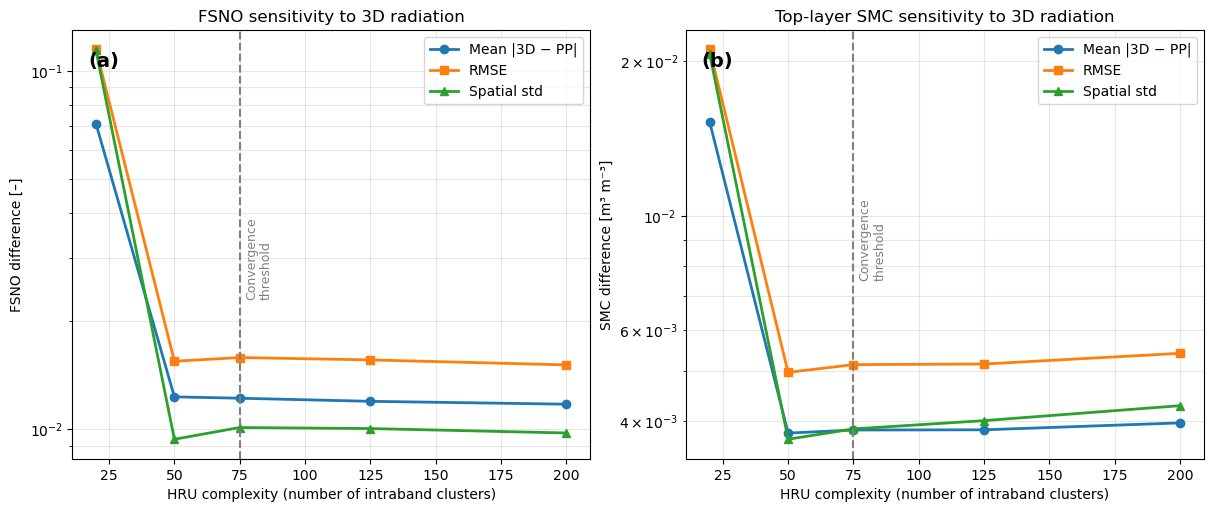

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/sensitivity_plots/HRU_Effects/Figure_D2_3D_minus_PP_metrics_by_HRU_clusters_LOG.png


In [42]:
# --------------------------------------------------
# FIGURE D2: METRIC CURVES (LOG SCALE)
# --------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    constrained_layout=True
)

# ==================================================
# (a) FSNO
# ==================================================
axes[0].plot(
    clusters,
    fsno_mean_abs,
    marker="o",
    linewidth=2,
    label="Mean |3D − PP|"
)

axes[0].plot(
    clusters,
    fsno_rmse,
    marker="s",
    linewidth=2,
    label="RMSE"
)

axes[0].plot(
    clusters,
    fsno_std,
    marker="^",
    linewidth=2,
    label="Spatial std"
)

# --------------------------------------------------
# CONVERGENCE THRESHOLD
# --------------------------------------------------
axes[0].axvline(
    75,
    color="gray",
    linestyle="--",
    linewidth=1.5
)

axes[0].text(
    77,
    0.03,
    "Convergence\nthreshold",
    rotation=90,
    fontsize=9,
    color="gray",
    va="center"
)

# --------------------------------------------------
# LOG SCALE
# --------------------------------------------------
axes[0].set_yscale("log")

# --------------------------------------------------
# TITLES / LABELS
# --------------------------------------------------
axes[0].set_title("FSNO sensitivity to 3D radiation")

axes[0].set_xlabel(
    "HRU complexity (number of intraband clusters)"
)

axes[0].set_ylabel(
    "FSNO difference [–]"
)

# --------------------------------------------------
# PANEL LABEL
# --------------------------------------------------
axes[0].text(
    0.03,
    0.95,
    "(a)",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

# --------------------------------------------------
# GRID / LEGEND
# --------------------------------------------------
axes[0].grid(alpha=0.3, which="both")
axes[0].legend()

# ==================================================
# (b) SMC
# ==================================================
axes[1].plot(
    clusters,
    smc_mean_abs,
    marker="o",
    linewidth=2,
    label="Mean |3D − PP|"
)

axes[1].plot(
    clusters,
    smc_rmse,
    marker="s",
    linewidth=2,
    label="RMSE"
)

axes[1].plot(
    clusters,
    smc_std,
    marker="^",
    linewidth=2,
    label="Spatial std"
)

# --------------------------------------------------
# CONVERGENCE THRESHOLD
# --------------------------------------------------
axes[1].axvline(
    75,
    color="gray",
    linestyle="--",
    linewidth=1.5
)

axes[1].text(
    77,
    0.009,
    "Convergence\nthreshold",
    rotation=90,
    fontsize=9,
    color="gray",
    va="center"
)

# --------------------------------------------------
# LOG SCALE
# --------------------------------------------------
axes[1].set_yscale("log")

# --------------------------------------------------
# TITLES / LABELS
# --------------------------------------------------
axes[1].set_title(
    "Top-layer SMC sensitivity to 3D radiation"
)

axes[1].set_xlabel(
    "HRU complexity (number of intraband clusters)"
)

axes[1].set_ylabel(
    "SMC difference [m³ m⁻³]"
)

# --------------------------------------------------
# PANEL LABEL
# --------------------------------------------------
axes[1].text(
    0.03,
    0.95,
    "(b)",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

# --------------------------------------------------
# GRID / LEGEND
# --------------------------------------------------
axes[1].grid(alpha=0.3, which="both")
axes[1].legend()

# --------------------------------------------------
# SAVE
# --------------------------------------------------
outfile = os.path.join(
    outputdir,
    "Figure_D2_3D_minus_PP_metrics_by_HRU_clusters_LOG.png"
)

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", outfile)

In [ ]:

#compares your model FSNO against MODSCAG snow fraction defualt configuration
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "PP_downscale_new": {
        "path": base + "/MSWX_3h_Snow_Project3_pp_downscale_new/",
        "physics": "PP",
    },
    "3D_downscale_new": {
        "path": base + "/MSWX_3h_Snow_Project3_3d_downscale_new/",
        "physics": "3D",
    },
}

modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/downscale_new_MODSCAG_metrics"
os.makedirs(outputdir, exist_ok=True)

buffer = 250

seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

def read_model_var(path, varname="fsno"):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables[varname][:])
    fp.close()
    return data

def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

def model_season_map(path, season_months, varname="fsno"):
    data = read_model_var(path, varname)

    ntime = data.shape[0]
    times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

    mask = times.month.isin(season_months)
    mean_hru = np.nanmean(data[mask, :], axis=0)

    hrus = gdal_tools.read_raster(path + "/postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "/postprocess/cids.vrt")
    tmp = np.full(hrus.shape, -9999.0)

    grid = place_data(tmp, mean_hru, hrus, cids, 1)
    grid = np.where(grid == -9999.0, np.nan, grid)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]

pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []

    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue

        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)

        if 2016 <= dt.year <= 2018:
            rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError("No MODSCAG files found for 2016–2018")

    return rows

def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()

    return arr / 100.0

def modscag_season_map(rows, season_months):
    arrs = []

    for dt, fp in rows:
        if dt.month in season_months:
            arrs.append(read_modscag_grid(fp))

    if len(arrs) == 0:
        return None

    grid = np.nanmean(np.stack(arrs, axis=0), axis=0)

    return grid[
        buffer:grid.shape[0]-buffer+1,
        buffer:grid.shape[1]-buffer+1
    ]

def calc_metrics(model_map, obs_map):
    valid = np.isfinite(model_map) & np.isfinite(obs_map)

    if np.sum(valid) == 0:
        return np.nan, np.nan, np.nan, np.nan

    diff = model_map[valid] - obs_map[valid]

    bias = np.nanmean(diff)
    rmse = np.sqrt(np.nanmean(diff**2))
    mae = np.nanmean(np.abs(diff))
    corr = np.corrcoef(model_map[valid].ravel(), obs_map[valid].ravel())[0, 1]

    return bias, rmse, mae, corr

modscag_rows = build_modscag_rows(modscag_sat)

rows = []

for run_name, info in runs.items():
    path = info["path"]

    print("Processing:", run_name)

    for season, months in seasons.items():

        model_map = model_season_map(path, months, varname="fsno")
        obs_map = modscag_season_map(modscag_rows, months)

        if obs_map is None:
            continue

        if model_map.shape != obs_map.shape:
            raise ValueError(f"Shape mismatch: {model_map.shape} vs {obs_map.shape}")

        bias, rmse, mae, corr = calc_metrics(model_map, obs_map)

        rows.append({
            "run": run_name,
            "physics": info["physics"],
            "season": season,
            "bias": bias,
            "rmse": rmse,
            "mae": mae,
            "corr": corr,
        })

df_downscale_metrics = pd.DataFrame(rows)

outfile = os.path.join(outputdir, "PP_3D_downscale_new_FSNO_MODSCAG_metrics.csv")
df_downscale_metrics.to_csv(outfile, index=False)

print("Saved:", outfile)
df_downscale_metrics

Processing: PP_downscale_new


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1666733/2615070009.py:110: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1666733/2615070009.py:110: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing: 3D_downscale_new


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1666733/2615070009.py:110: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_1666733/2615070009.py:110: RuntimeWarning: Mean of empty slice
  grid = np.nanmean(np.stack(arrs, axis=0), axis=0)


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/downscale_new_MODSCAG_metrics/PP_3D_downscale_new_FSNO_MODSCAG_metrics.csv


,run,physics,season,bias,rmse,mae,corr
0,PP_downscale_new,PP,Winter,0.324046,0.379952,0.332269,0.667176
1,PP_downscale_new,PP,Spring,0.147561,0.281700,0.158342,0.550573
2,PP_downscale_new,PP,Summer,0.004281,0.022345,0.005158,0.180467
3,PP_downscale_new,PP,Fall,0.053379,0.068796,0.058103,0.598997
4,3D_downscale_new,3D,Winter,0.320361,0.379417,0.330315,0.634979
5,3D_downscale_new,3D,Spring,0.139228,0.272364,0.155858,0.510005
6,3D_downscale_new,3D,Summer,0.004564,0.024442,0.005511,0.166745
7,3D_downscale_new,3D,Fall,0.053411,0.069550,0.059131,0.553609


In [ ]:
import netCDF4 as nc
import os

#base = "/Users/bernardnkrumahattobrah/Documents/HydroBlocks/data/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_Bernard"
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_septiles_downscale_test_5/"
cid = 1

input_file = os.path.join(path_pp, f"{cid}/input_file.nc")
output_file = os.path.join(path_pp, f"output_data/{cid}/2016-01-01.nc")

def list_nc_vars(path):
    print(f"\n--- File: {path} ---")
    with nc.Dataset(path) as ds:
        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(f"  {vname:20s} shape={var.shape} dims={var.dimensions}")

# Inspect static (parameters/meteorology)
list_nc_vars(input_file)

# Inspect dynamic outputs
list_nc_vars(output_file)



--- File: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_septiles_downscale_test_5/1/input_file.nc ---

[Group: meteorology]
  lwdown               shape=(8744, 800) dims=('time', 'hru')
  swdown               shape=(8744, 800) dims=('time', 'hru')
  tair                 shape=(8744, 800) dims=('time', 'hru')
  precip               shape=(8744, 800) dims=('time', 'hru')
  psurf                shape=(8744, 800) dims=('time', 'hru')
  wind                 shape=(8744, 800) dims=('time', 'hru')
  spfh                 shape=(8744, 800) dims=('time', 'hru')
  time                 shape=(8744,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                 shape=(4,) dims=('connections_columns',)
  indices              shape=(4,) dims=('connections_columns',)
  indptr               shape=(3,) dims=('connections_rows',)

[Group: wmatrix_Basin2]
  data                 shape=(4,) dims=('connecti

In [1]:
import netCDF4 as nc
import numpy as np

input_file = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025/1/input_file.nc"

with nc.Dataset(input_file) as ds:
    lats = ds["parameters"]["lats"][:]
    lons = ds["parameters"]["lons"][:]
    dem  = ds["parameters"]["dem"][:]

print("Latitude range :", np.nanmin(lats), "to", np.nanmax(lats))
print("Longitude range:", np.nanmin(lons), "to", np.nanmax(lons))
print("Elevation range:", np.nanmin(dem), "to", np.nanmax(dem))
print("Number of HRUs:", len(lats))

Latitude range : 35.313755 to 36.232246
Longitude range: -106.15083 to -105.202225
Elevation range: 1698.6074 to 3588.85
Number of HRUs: 200
